# CSV / Matrix Flow Cytometry Analysis

Analyze flow cytometry data exported as CSV or tabular matrices (e.g. from FlowJo, FACS Diva).  
This notebook does **not** require .fcs files — just a CSV with columns for each parameter.

## 1. Setup

In [1]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(readr)
library(uwot)
library(Rtsne)
library(viridis)
library(patchwork)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: viridisLite



## 2. Load data

In [2]:
# -- Point this to your CSV file --
data_path <- "../data/matrix_data.csv"
df <- read_csv(data_path, show_col_types = FALSE)

dim(df)
head(df)
summary(df)

[1] 13982     4

FSC-A,SSC-A,Alexa_488-A,PI-A
<dbl>,<dbl>,<dbl>,<dbl>
106737.00,34943.1,1182.820,115.2120
6390.56,13911.8,277.841,54.4942
252124.00,84884.6,4916.180,154.5880
262143.00,204461.0,5511.650,557.2780
262143.00,133109.0,4741.050,349.7930
262143.00,186757.0,7275.760,485.4910


     FSC-A            SSC-A         Alexa_488-A            PI-A         
 Min.   :  5137   Min.   :  1004   Min.   :   -40.2   Min.   : -149.69  
 1st Qu.:107128   1st Qu.: 39094   1st Qu.:  2169.0   1st Qu.:   73.31  
 Median :122079   Median : 50406   Median :  3574.8   Median :  116.73  
 Mean   :124505   Mean   : 60720   Mean   : 11082.5   Mean   :  663.86  
 3rd Qu.:139020   3rd Qu.: 67562   3rd Qu.:  6740.3   3rd Qu.:  182.42  
 Max.   :262143   Max.   :262143   Max.   :260470.0   Max.   :87389.00  

## 3. Channel overview

In [3]:
channels <- colnames(df)
cat("Channels:", paste(channels, collapse = ", "), "\n")
cat("Events:", nrow(df), "\n")

Channels: FSC-A, SSC-A, Alexa_488-A, PI-A 
Events: 13982 


## 4. Distributions — histograms per channel

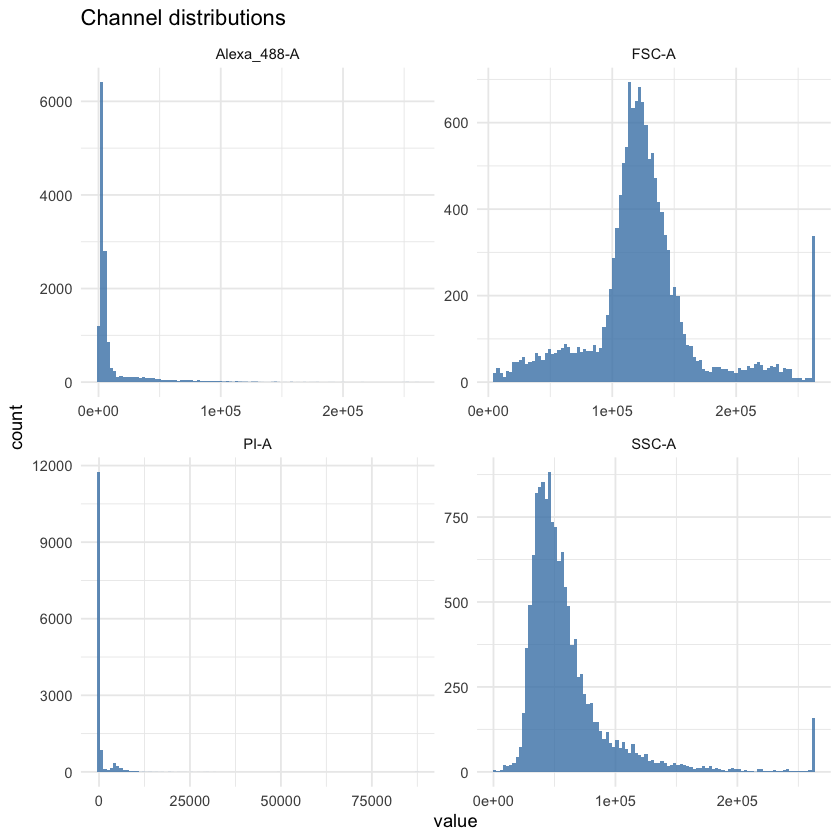

In [4]:
df_long <- df %>%
    mutate(event_id = row_number()) %>%
    pivot_longer(-event_id, names_to = "channel", values_to = "value")

ggplot(df_long, aes(x = value)) +
    geom_histogram(bins = 100, fill = "steelblue", color = NA, alpha = 0.8) +
    facet_wrap(~channel, scales = "free") +
    theme_minimal() +
    labs(title = "Channel distributions")

## 5. Scatter plots

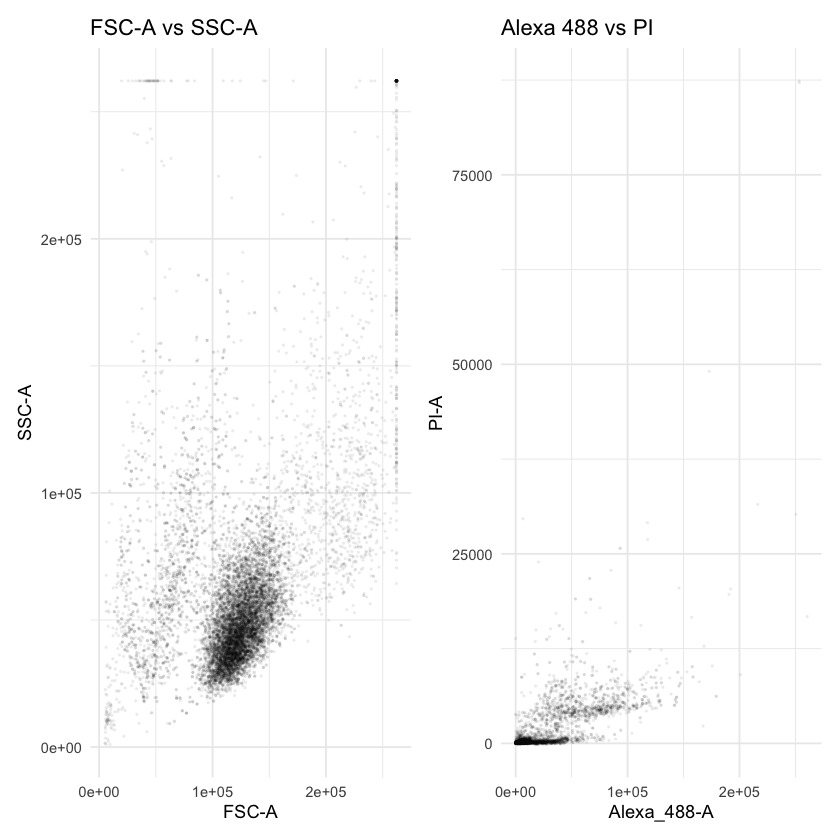

In [5]:
# FSC vs SSC — cell size / granularity
p1 <- ggplot(df, aes(x = `FSC-A`, y = `SSC-A`)) +
    geom_point(alpha = 0.05, size = 0.3) +
    theme_minimal() +
    labs(title = "FSC-A vs SSC-A")

# Fluorescence channels
p2 <- ggplot(df, aes(x = `Alexa_488-A`, y = `PI-A`)) +
    geom_point(alpha = 0.05, size = 0.3) +
    theme_minimal() +
    labs(title = "Alexa 488 vs PI")

p1 + p2

## 6. Density plots

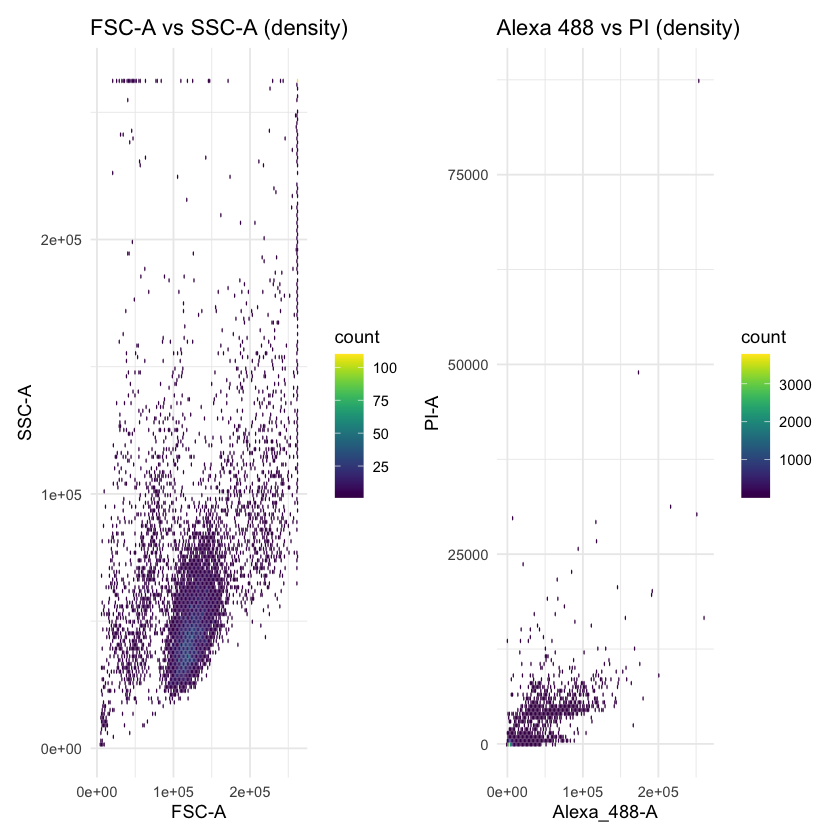

In [6]:
p3 <- ggplot(df, aes(x = `FSC-A`, y = `SSC-A`)) +
    geom_hex(bins = 150) +
    scale_fill_viridis() +
    theme_minimal() +
    labs(title = "FSC-A vs SSC-A (density)")

p4 <- ggplot(df, aes(x = `Alexa_488-A`, y = `PI-A`)) +
    geom_hex(bins = 150) +
    scale_fill_viridis() +
    theme_minimal() +
    labs(title = "Alexa 488 vs PI (density)")

p3 + p4

## 7. Manual gating

Define thresholds to gate populations. Adjust these values based on your data.

In [7]:
# -- Adjust thresholds --
fsc_min <- 50000
fsc_max <- 250000
ssc_max <- 200000

df <- df %>%
    mutate(
        gate_scatter = (`FSC-A` > fsc_min & `FSC-A` < fsc_max & `SSC-A` < ssc_max),
        gate_live = (gate_scatter & `PI-A` < 500),        # PI-low = live
        gate_positive = (gate_live & `Alexa_488-A` > 5000) # Alexa 488+
    )

cat("Total events:", nrow(df), "\n")
cat("In scatter gate:", sum(df$gate_scatter), "\n")
cat("Live (PI-):", sum(df$gate_live), "\n")
cat("Alexa 488+:", sum(df$gate_positive), "\n")

Total events: 13982 
In scatter gate: 12784 
Live (PI-): 11634 
Alexa 488+: 2685 


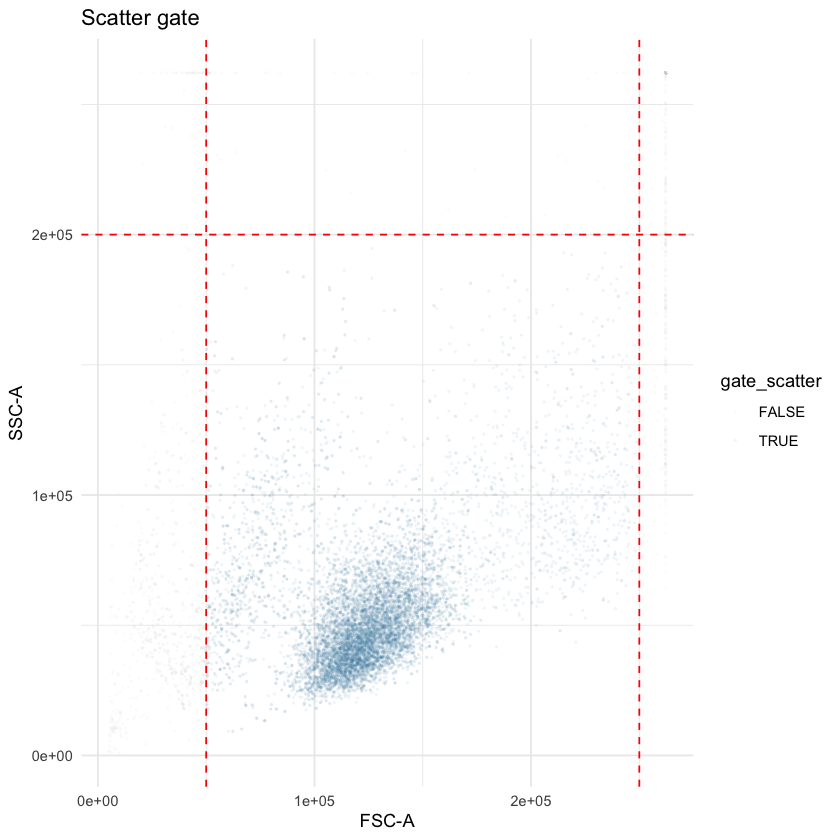

In [8]:
# Visualize gates
ggplot(df, aes(x = `FSC-A`, y = `SSC-A`, color = gate_scatter)) +
    geom_point(alpha = 0.05, size = 0.3) +
    scale_color_manual(values = c("grey80", "steelblue")) +
    geom_vline(xintercept = c(fsc_min, fsc_max), linetype = "dashed", color = "red") +
    geom_hline(yintercept = ssc_max, linetype = "dashed", color = "red") +
    theme_minimal() +
    labs(title = "Scatter gate")

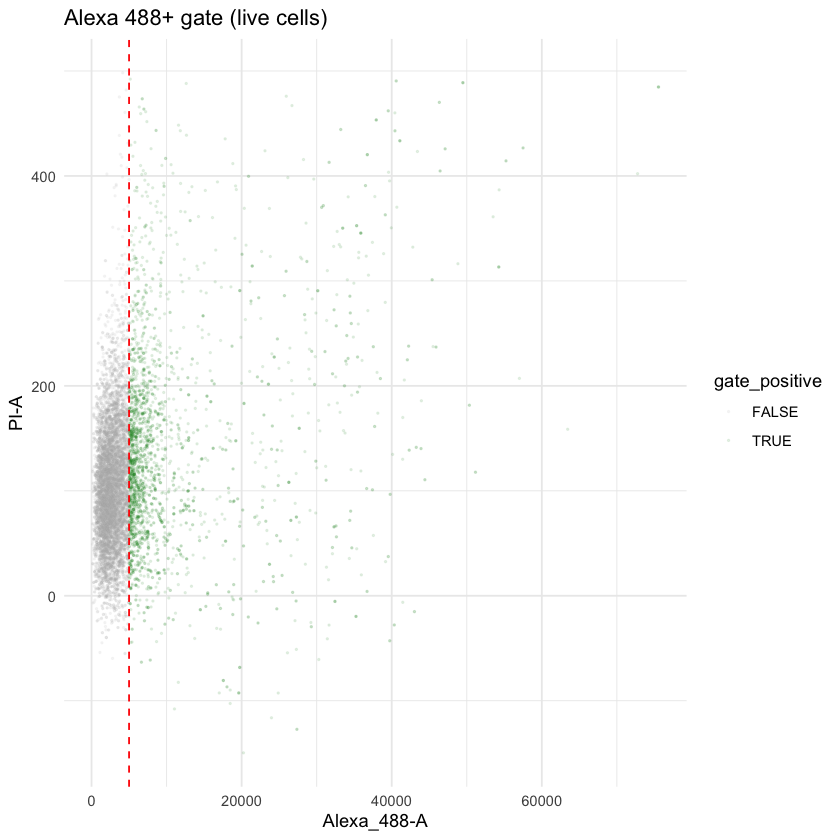

In [9]:
gated <- df %>% filter(gate_live)

ggplot(gated, aes(x = `Alexa_488-A`, y = `PI-A`, color = gate_positive)) +
    geom_point(alpha = 0.1, size = 0.3) +
    scale_color_manual(values = c("grey70", "forestgreen")) +
    geom_vline(xintercept = 5000, linetype = "dashed", color = "red") +
    theme_minimal() +
    labs(title = "Alexa 488+ gate (live cells)")

## 8. Dimensionality reduction — UMAP

In [10]:
# Use gated live cells
mat <- gated %>% select(`FSC-A`, `SSC-A`, `Alexa_488-A`, `PI-A`) %>% as.matrix()

# Scale
mat_scaled <- scale(mat)

# Subsample if large (>10k events)
set.seed(42)
n_sub <- min(nrow(mat_scaled), 10000)
idx <- sample(nrow(mat_scaled), n_sub)
mat_sub <- mat_scaled[idx, ]

umap_res <- uwot::umap(mat_sub, n_neighbors = 15, min_dist = 0.2, metric = "euclidean")

umap_df <- data.frame(
    UMAP1 = umap_res[, 1],
    UMAP2 = umap_res[, 2],
    Alexa488 = mat[idx, "Alexa_488-A"],
    PI = mat[idx, "PI-A"]
)

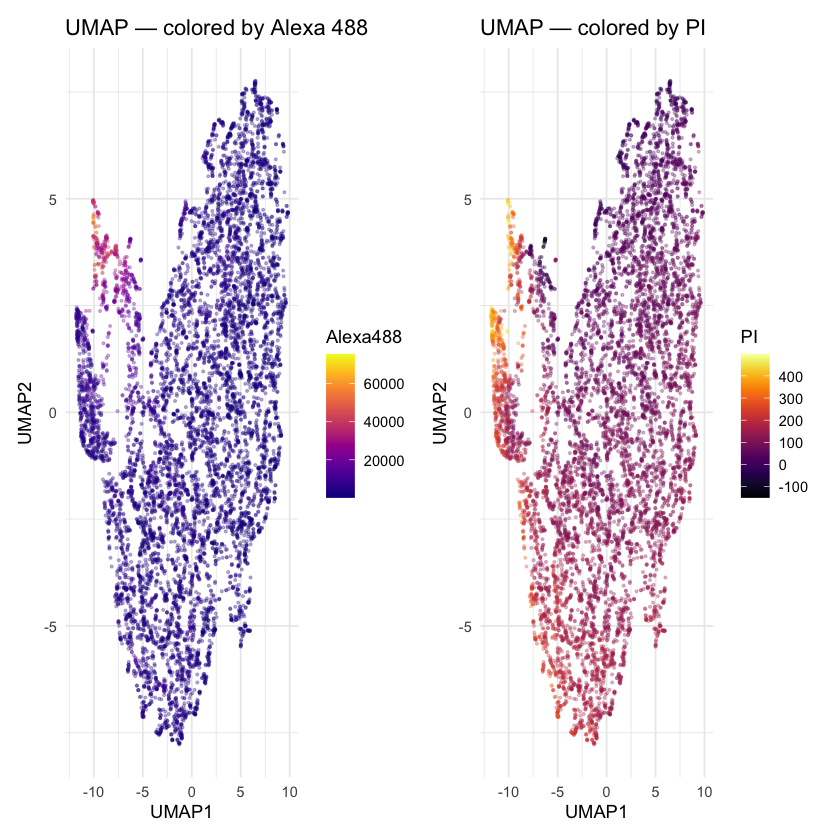

In [11]:
p5 <- ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = Alexa488)) +
    geom_point(alpha = 0.3, size = 0.5) +
    scale_color_viridis(option = "C") +
    theme_minimal() +
    labs(title = "UMAP — colored by Alexa 488")

p6 <- ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = PI)) +
    geom_point(alpha = 0.3, size = 0.5) +
    scale_color_viridis(option = "B") +
    theme_minimal() +
    labs(title = "UMAP — colored by PI")

p5 + p6

## 9. Clustering — k-means

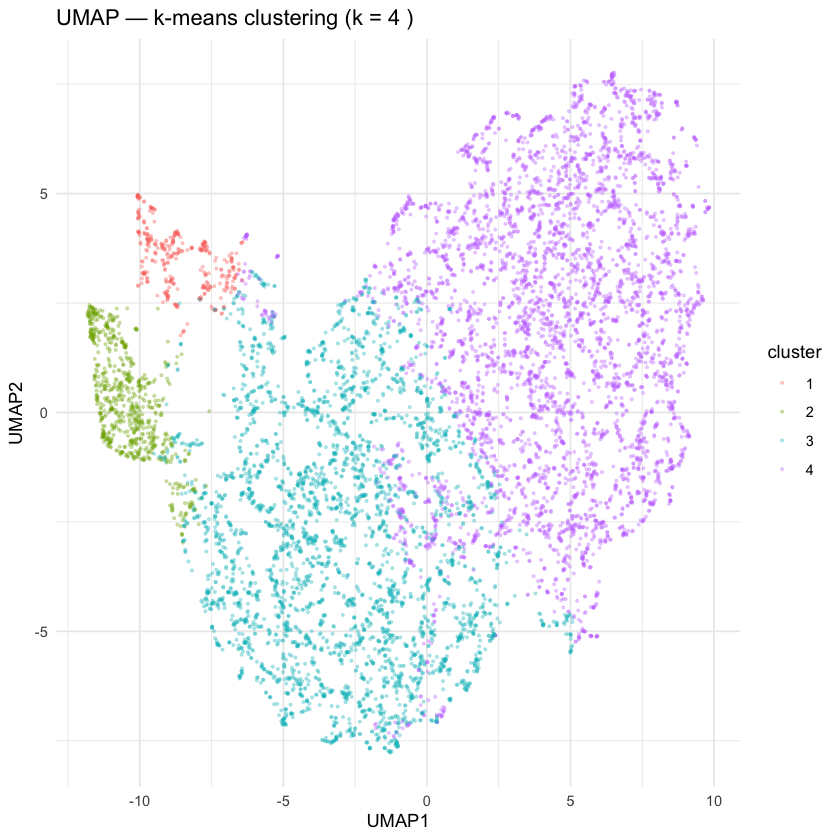

In [12]:
set.seed(42)
k <- 4  # adjust as needed
km <- kmeans(mat_sub, centers = k, nstart = 25)

umap_df$cluster <- factor(km$cluster)

ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = cluster)) +
    geom_point(alpha = 0.3, size = 0.5) +
    theme_minimal() +
    labs(title = paste("UMAP — k-means clustering (k =", k, ")"))

## 10. Cluster summary

In [13]:
cluster_summary <- gated[idx, ] %>%
    mutate(cluster = km$cluster) %>%
    group_by(cluster) %>%
    summarise(
        n = n(),
        FSC_mean = mean(`FSC-A`),
        SSC_mean = mean(`SSC-A`),
        Alexa488_mean = mean(`Alexa_488-A`),
        PI_mean = mean(`PI-A`),
        .groups = "drop"
    )

cluster_summary

cluster,n,FSC_mean,SSC_mean,Alexa488_mean,PI_mean
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,363,125411.3,81672.75,31944.487,207.14268
2,719,207539.8,101922.61,6531.077,226.85255
3,3861,134555.9,59200.13,4218.227,137.21811
4,5057,116383.9,39550.71,2935.647,71.47929


## 11. t-SNE (alternative)

Slower than UMAP but sometimes reveals different structure.

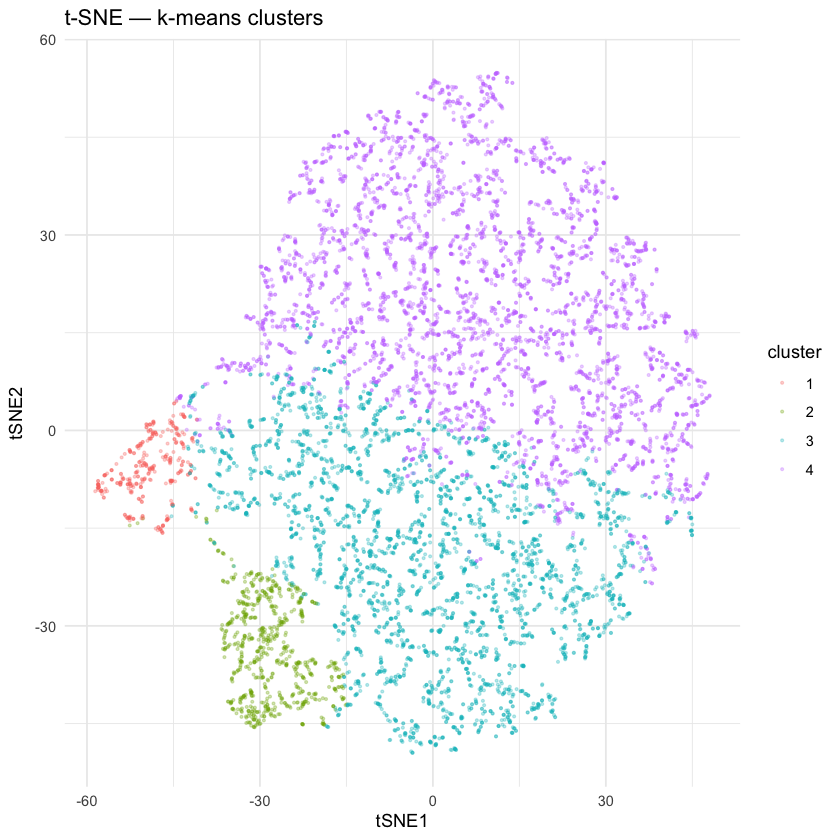

In [14]:
set.seed(42)
tsne_res <- Rtsne::Rtsne(mat_sub, dims = 2, perplexity = 30, max_iter = 1000,
                          check_duplicates = FALSE)

tsne_df <- data.frame(
    tSNE1 = tsne_res$Y[, 1],
    tSNE2 = tsne_res$Y[, 2],
    cluster = factor(km$cluster)
)

ggplot(tsne_df, aes(x = tSNE1, y = tSNE2, color = cluster)) +
    geom_point(alpha = 0.3, size = 0.5) +
    theme_minimal() +
    labs(title = "t-SNE — k-means clusters")

## 12. Save results

In [15]:
out_dir <- "../data/results"
dir.create(out_dir, showWarnings = FALSE)

# Gated cells (subsampled) with cluster assignments and UMAP coords
gated_export <- gated[idx, ] %>%
    mutate(
        cluster = km$cluster,
        UMAP1 = umap_df$UMAP1,
        UMAP2 = umap_df$UMAP2
    )

write_csv(gated_export, file.path(out_dir, "01_gated_clustered.csv"))
write_csv(cluster_summary, file.path(out_dir, "01_cluster_summary.csv"))
cat("Saved to", out_dir, "\n")

Saved to ../data/results 
